In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
# rc('text', usetex=True)

In [2]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/paper_bas/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/anti_{experiment_name.value}")
# experiment_dir = Path(f"/dcs/large/u1508153/misdro/debug/symmetric_{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/kl_pp")

assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df = all_results_df.loc[all_results_df["num_test_observations"] == 50]
all_results_df.tail(3)

solution  \
uuid                                 replication                        
05c2bd6e-cc3b-438e-a072-e82ce888659d 497          [42.04752130459398]   
                                     498          [41.43830716729283]   
                                     499          [36.73763202027572]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
05c2bd6e-cc3b-438e-a072-e82ce888659d 497          0.000245         0.000073   
                                     498          0.000217         0.000071   
                                     499          0.000222         0.000071   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
05c2bd6e-cc3b-438e-a072-e82ce888659d 497                0.000209    0.635873   
                                     498                0.000202    0.677486   
                                     499                0.000209    0.633761   

                                                  setup_time  \
uuid                                 replication               
05c2bd6e-cc3b-438e-a072-e82ce888659d 497                 NaN   
                                     498                 NaN   
                                     499                 NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
05c2bd6e-cc3b-438e-a072-e82ce888659d 497                             0.0   
                                     498                             0.0   
                                     499                             0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
05c2bd6e-cc3b-438e-a072-e82ce888659d 497          [81.82135981335952, 25.67326412982974, 87.7891...   
                                     498          [55.35764031171022, 17.578696044437038, 20.489...   
                                     499          [17.673599014737263, 20.53596548199808, 39.261...   

                                                 algorithm  contamination  \
uuid                                 replication                            
05c2bd6e-cc3b-438e-a072-e82ce888659d 497           kl_bdro            0.0   
                                     498           kl_bdro            0.0   
                                     499           kl_bdro            0.0   

                                                  ... inference lengthscale  \
uuid                                 replication  ...                         
05c2bd6e-cc3b-438e-a072-e82ce888659d 497          ...     bayes        -1.0   
                                     498          ...     bayes        -1.0   
                                     499          ...     bayes        -1.0   

                                                  likelihood  njobs  \
uuid                                 replication                      
05c2bd6e-cc3b-438e-a072-e82ce888659d 497              normal      1   
                                     498              normal      1   
                                     499              normal      1   

                                                  num_likelihood_samples  \
uuid                                 replication                           
05c2bd6e-cc3b-438e-a072-e82ce888659d 497                              30   
                                     498                              30   
                                     499                              30   

                                                 num_observations  \
uuid                                 replication                    
05c2bd6e-cc3b-438e-a072

In [3]:
filter_dgp = "normal"  # filter by DGP
results_df = preprocess_results_df(all_results_df, filter_dgp)
results_df.head(3)


solution  \
uuid                                 replication                         
5c224360-bad5-4e04-a729-e8659d2479ae 0            [26.504853109137507]   
                                     1            [29.879991219010936]   
                                     2             [34.51079683893437]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
5c224360-bad5-4e04-a729-e8659d2479ae 0            0.000363         0.000102   
                                     1            0.000220         0.000083   
                                     2            0.000233         0.000090   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
5c224360-bad5-4e04-a729-e8659d2479ae 0                  0.000061    0.041515   
                                     1                  0.000054    0.026594   
                                     2                  0.000055    0.025303   

                                                  setup_time  \
uuid                                 replication               
5c224360-bad5-4e04-a729-e8659d2479ae 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
5c224360-bad5-4e04-a729-e8659d2479ae 0                               0.0   
                                     1                               0.0   
                                     2                               0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
5c224360-bad5-4e04-a729-e8659d2479ae 0            [8.370599215733552, 97.27825277087481, 24.4703...   
                                     1            [14.395708241482502, 22.90806081601392, 64.485...   
                                     2            [3.288441345698814, 22.89133790738252, 18.6152...   

                                                 algorithm  contamination  \
uuid                                 replication                            
5c224360-bad5-4e04-a729-e8659d2479ae 0               kl_pp            0.0   
                                     1               kl_pp            0.0   
                                     2               kl_pp            0.0   

                                                  ... num_likelihood_samples  \
uuid                                 replication  ...                          
5c224360-bad5-4e04-a729-e8659d2479ae 0            ...                     25   
                                     1            ...                     25   
                                     2            ...                     25   

                                                 num_observations  \
uuid                                 replication                    
5c224360-bad5-4e04-a729-e8659d2479ae 0                         20   
                                     1                         20   
                                     2                         20   

                                                  num_posterior_samples  \
uuid                                 replication                          
5c224360-bad5-4e04-a729-e8659d2479ae 0                                1   
                                     1                                1   
                                     2                                1   

                                                  num_replications  \
uuid                                 replication                     
5c224360-bad5-4e04-a729-e86

In [4]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f3c183a9b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7f3c183a9c60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm  dgp    epsilon num_total_samples                       
kl_bdro    normal 0.001   25                          39.210286   
                          100                         37.910862   
                          900                         37.555099   
                  0.003   25                          39.155725   
                          100                         37.932119   
                          900                         37.592952   
                  0.010   25                          39.063248   
                          100                         37.996485   
                          900                         37.675137   
                  0.030   25                          39.045300   
                          100                         38.121156   
                          900                         37.847570   
                  0.100   25                          39.148776   
                          100                         38.417752   
                          900                         38.283811   
                  0.300   25                          39.656783   
                          100                         39.073791   
                          900                         39.183252   
                  1.000   25                          40.592444   
                          100                         40.573189   
                          900                         41.320495   
                  3.000   25                          40.568599   
                          100                         42.794227   
                          900                         44.858377   
kl_dro_bas normal 0.100   25                          39.009460   
                          100                         38.127090   
                          900                         37.920417   
                  0.300   25                          39.782496   
                          100                         39.205035   
                          900                         39.125379   
                  1.000   25                          41.570545   
                          100                         42.191204   
                          900                         42.773505   
                  3.000   25                          41.526191   
                          100                         44.612229   
                          900                         49.804968   
kl_pp      normal 0.001   25                          39.029454   
                          100                         37.876181   
                          900                         37.594431   
                  0.003   25                          38.986493   
                          100                         37.898104   
                          900                         37.642210   
                  0.010   25                          38.885068   
                          100                         37.990130   
                          900                         37.745026   
                  0.030   25                          39.030520   
                          100                         38.225804   
                          900                         37.976714   
                  0.100   25                          39.455248   
                          100                         38.853258   
                          900                         38.616580   
                  0.300   25                          40.638068   
                          100                         40.480824   
                          900                         40.223847   
                  1.000   25                          42.870091   
                          100                         45.169909   
                          900                         45.647637   
                  3.000   25                          42.820576   
                         

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

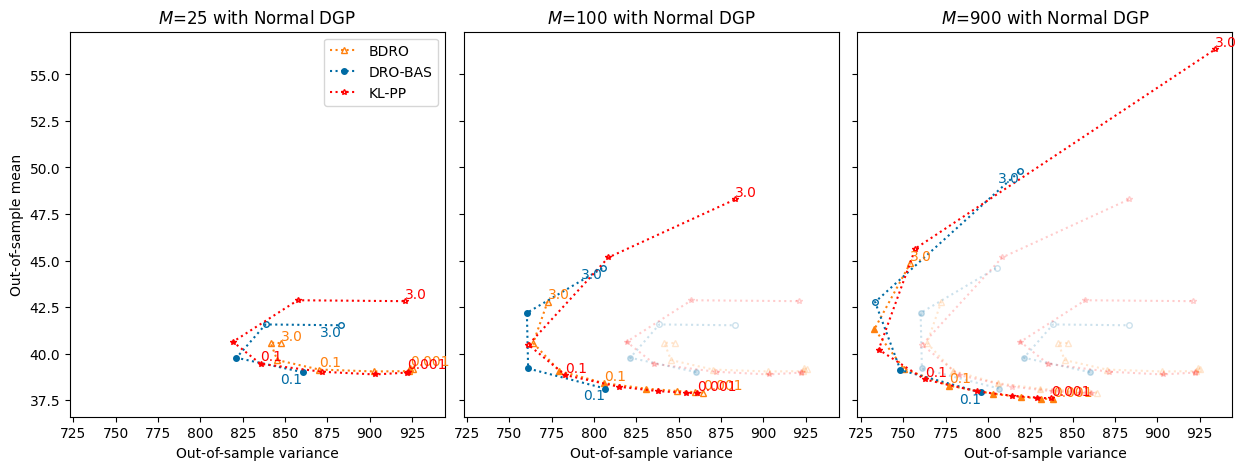

In [5]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
# total_samples_list = [900]
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
# axes = np.array([axes])
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)

for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            for k in range(j, len(total_samples_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend()
            axes[j].set_ylabel("Out-of-sample mean")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

# Plot sum of in-group variance and variance of in-group mean
Let $m$ be the number of test observations.
Let $k$ be the number of replications.
Let $\xi_{ij}$ be the $i^{\text{th}}$ test observation for replication $j$.
For a given replication $j$, the in-group mean and variance is
$$\mu_j = \frac{1}{m}\sum_{i=1}^m f(x_j, \xi_{ij}), \hspace{2em} v_j = \frac{1}{m-1}\sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \mu_j \right)^2$$

We define the mean across all replications and all test observations as
$$\bar{\mu} = \frac{1}{mk} \sum_{j=1}^k \sum_{i=1}^m f(x_j, \xi_{ij}).$$

The total variance is defined by $$\frac{1}{mk-1}\sum_{j=1}^k \sum_{i=1}^m \left( f(x_j, \xi_{ij}) - \bar{\mu} \right)^2.$$
This can be decomposed into two terms.
The first is a constant times the sum of the in-group variances:
$$\frac{m-1}{km - 1} \sum^k_{j=1} v_j,$$
and the second term is a constant times the variance of the in-group means:
$$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j).$$


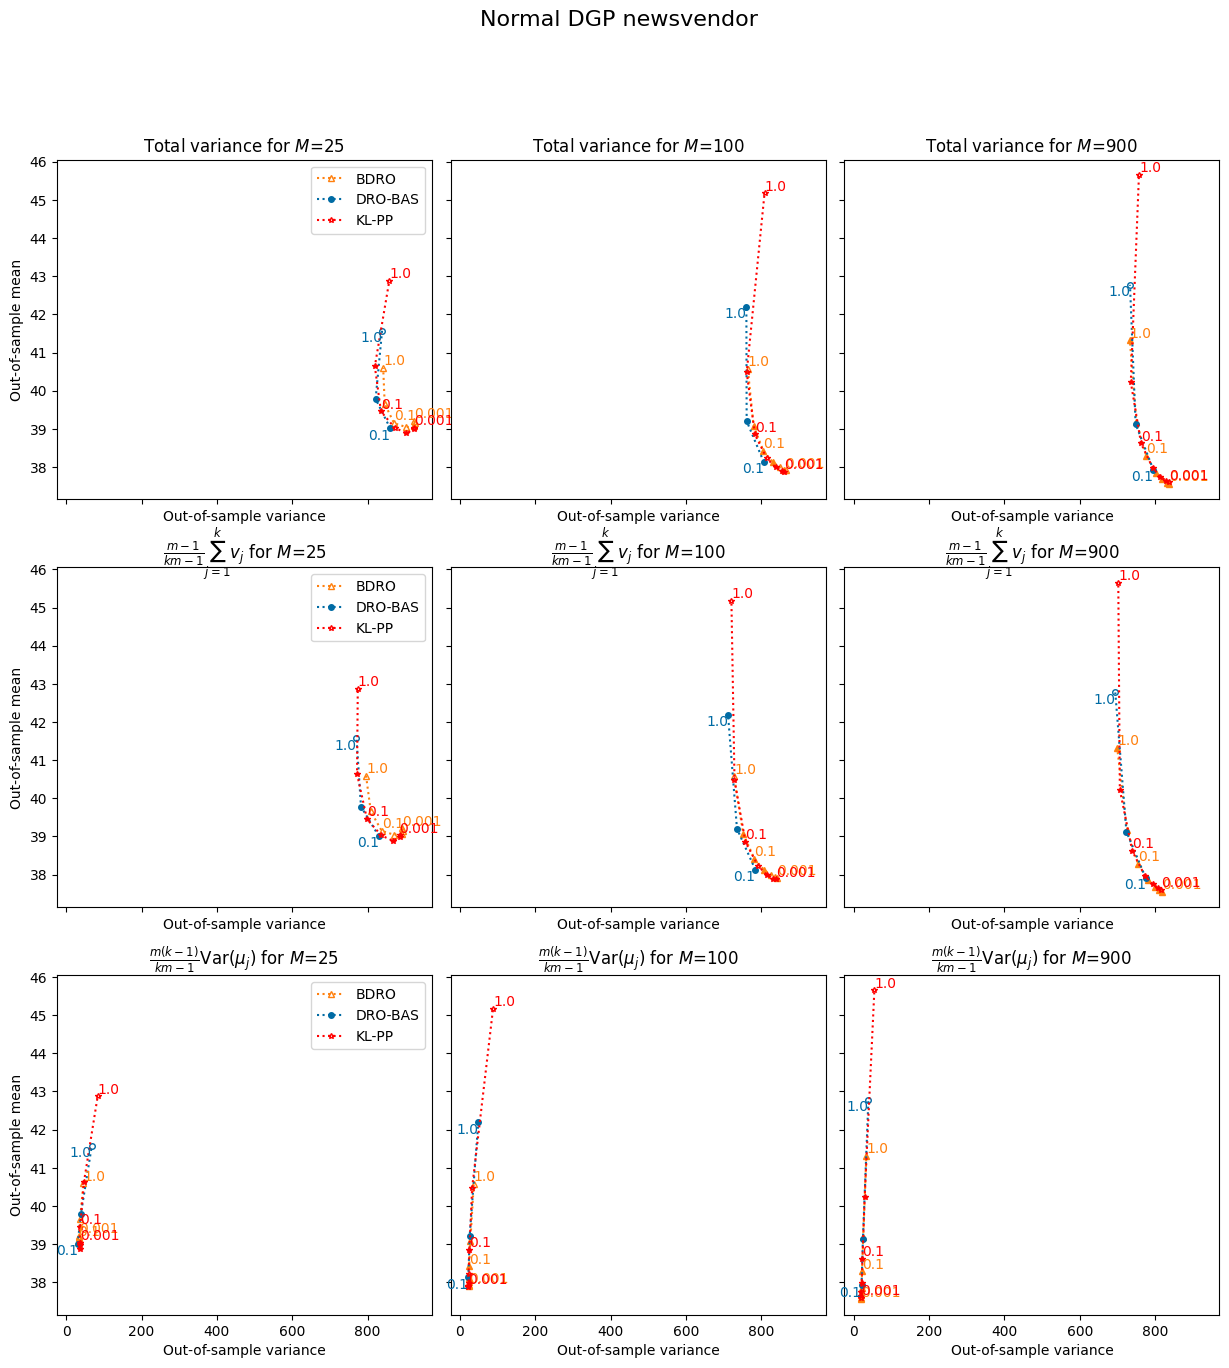

In [6]:
total_samples_list = agg_df.index.get_level_values("num_total_samples").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = 3
ncols = len(total_samples_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
fig.suptitle(f"{NiceNameDGP[filter_dgp]} newsvendor", fontsize=16)

nice_var_names = {
    "out_of_sample_var": "Total variance",
    "sum_of_in_group_var": r"$\frac{m-1}{km - 1} \sum^k_{j=1} v_j$",
    "var_of_in_group_mean": r"$\frac{m(k-1)}{km - 1} \text{Var}(\mu_j)$",
}

for i, var_col in enumerate(["out_of_sample_var", "sum_of_in_group_var", "var_of_in_group_mean"]):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = agg_df.loc[:, dgp, :trim_epsilon, total_samples]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            df = axis_df.loc[algorithm, :]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[i][j], df, **algorithm_inference_style(algorithm, "bayes", label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, var_col=var_col)
        if j == 0:
            axes[i][j].legend()
            axes[i][j].set_ylabel("Out-of-sample mean")
        axes[i][j].set_title(nice_var_names[var_col] + " for $M$" + f"={total_samples}")
        axes[i][j].set_xlabel("Out-of-sample variance")

# fig.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")

## Solve & sampling time

In [7]:
solve_time_df = get_agg_df(results_df, ["algorithm", "num_total_samples"])
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lllllll}
\toprule
 & \multicolumn{3}{r}{str_solve_time} & \multicolumn{3}{r}{str_sample_time} \\
algorithm & kl_bdro & kl_dro_bas & kl_pp & kl_bdro & kl_dro_bas & kl_pp \\
num_total_samples &  &  &  &  &  &  \\
\midrule
25 & 0.0662 (0.0116) & 0.0226 (0.0034) & 0.0242 (0.0037) & 0.0001 (0.0) & 0.0001 (0.0) & 0.0001 (0.0) \\
100 & 0.143 (0.0196) & 0.0343 (0.0036) & 0.036 (0.0037) & 0.0002 (0.0) & 0.0001 (0.0) & 0.0001 (0.0) \\
900 & 0.6818 (0.0413) & 0.3963 (0.0182) & 0.4127 (0.0217) & 0.0003 (0.0) & 0.0001 (0.0) & 0.0002 (0.0) \\
\bottomrule
\end{tabular}



/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function mean at 0x7f3c183a9b20> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:192: FutureWarning: The provided callable <function std at 0x7f3c183a9c60> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


In [8]:
df = results_df.copy()
df["solution"] = df["solution"].map(lambda x: x[4])
nrows = len(dgp_list)
ncols = len(total_samples_list)
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
solution_df = df.groupby(["algorithm", "dgp", "epsilon", "num_total_samples"]).agg({"solution": ["mean", "std"]})
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
        axis_df = solution_df.loc[:, dgp, :, total_samples]
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            axes[j].errorbar(axis_df.loc[algorithm, :].index.get_level_values("epsilon"), axis_df.loc[algorithm, :]["solution"]["mean"], yerr=axis_df.loc[algorithm, :]["solution"]["std"], **algorithm_inference_style(algorithm, "bayes"))
        axes[j].set_xscale("log")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Epsilon")
        if j == 0:
            axes[j].set_ylabel("Solution")

IndexError: list index out of range